In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)

np.random.seed(42)


## 1. Load and inspect the data

In [3]:
df = pd.read_csv('/mnt/user-data/uploads/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


   RowNumber  CustomerId   Surname  ...  IsActiveMember EstimatedSalary Exited
0          1    15634602  Hargrave  ...               1       101348.88      1
1          2    15647311      Hill  ...               1       112542.58      0
2          3    15619304      Onio  ...               0       113931.57      1
3          4    15701354      Boni  ...               0        93826.63      0
4          5    15737888  Mitchell  ...               1        79084.10      0

[5 rows x 14 columns]

In [4]:
df.isnull().sum().sum()  # total missing values

np.int64(0)

In [5]:
df['Exited'].value_counts(normalize=True).rename('proportion')

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

The target is imbalanced: about 20% of customers exited. We'll use `class_weight='balanced'` where supported and look at precision/recall/F1/ROC-AUC, not just accuracy.

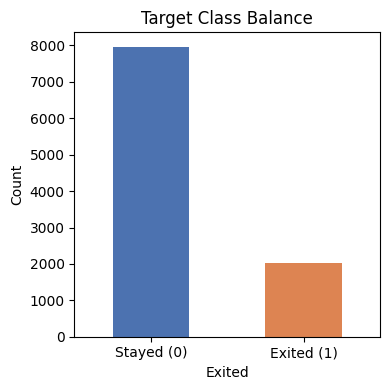

In [7]:
plt.figure(figsize=(4,4))
df['Exited'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.xticks([0,1], ['Stayed (0)', 'Exited (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Target Class Balance')
plt.tight_layout()
plt.show()

## 2. Preprocessing

Drop identifier columns (`RowNumber`, `CustomerId`, `Surname`) since they carry no predictive signal. One-hot encode `Geography`/`Gender`, standard-scale numeric features.

In [9]:
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

target = 'Exited'
X = df_model.drop(columns=[target])
y = df_model[target]

categorical_cols = ['Geography', 'Gender']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((8000, 10), (2000, 10))

## 3. Train and compare four classifiers

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Neural Net (MLP)': MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
}

results = []
fitted = {}
roc_data = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': auc})
    fitted[name] = pipe
    roc_data[name] = roc_curve(y_test, y_proba)

    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))


--- Logistic Regression ---
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
      Exited       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

--- Random Forest ---
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
      Exited       0.60      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000

--- Gradient Boosting ---
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
      Exited       0.77      0.50      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      200

In [12]:
results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
results_df

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0    Gradient Boosting    0.8670   0.768061  0.496314  0.602985  0.869347
1        Random Forest    0.8395   0.596847  0.651106  0.622797  0.862126
2     Neural Net (MLP)    0.8635   0.751880  0.491400  0.594354  0.855132
3  Logistic Regression    0.7140   0.387755  0.700246  0.499124  0.777182

In [13]:
best_name = results_df.iloc[0]['Model']
best_pipe = fitted[best_name]
print('Best model by ROC-AUC:', best_name)

Best model by ROC-AUC: Gradient Boosting


## 4. Confusion matrix (best model)

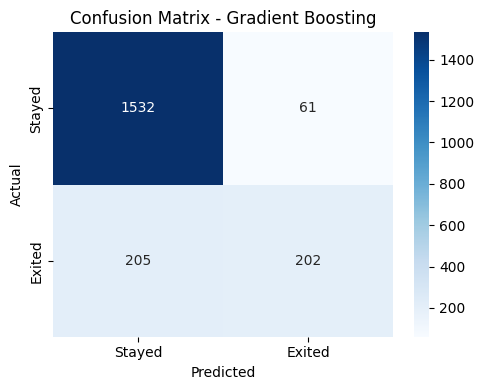

In [15]:
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Exited'], yticklabels=['Stayed','Exited'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

## 5. ROC curves — all models

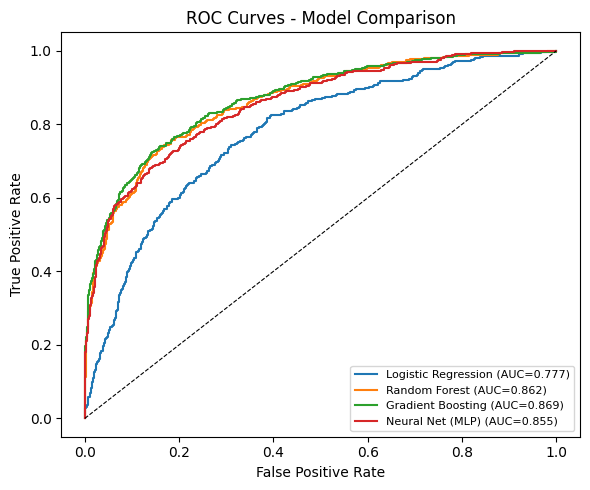

In [17]:
plt.figure(figsize=(6,5))
for name, (fpr, tpr, _) in roc_data.items():
    auc_val = results_df.loc[results_df['Model']==name, 'ROC_AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Feature importance (Random Forest)

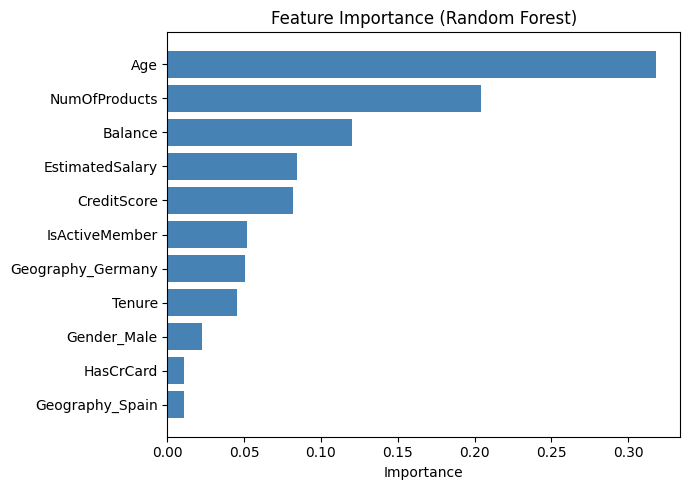

In [19]:
rf_pipe = fitted['Random Forest']
feature_names = numeric_cols + list(rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_cols))
importances = rf_pipe.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=True)

plt.figure(figsize=(7,5))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()